# Hantavirus network 
This code will create a network graph (Conversational Network) for bluesky data on the hantavirus and complete sentiment analysis comparing central users sentiment to other members of the community. 

---
### Import data and Libraries
This section of code imports the required libraries to be able to run the code and also imports the Hantavirus data from BlueSky.

In [3]:
#Import all required libraries
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import community as community_louvain
from collections import Counter
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sys
import string
import re
import nltk
import codecs
import emoji
import gensim
import random
import numpy as np
from datetime import datetime, date, timedelta
from collections import Counter
from collections import defaultdict
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer 
from nltk import bigrams
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from langdetect import DetectorFactory
from gensim.models import CoherenceModel
from gensim.models import LdaModel
from wordcloud import WordCloud
from gensim import corpora
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/matthewbeattie/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
#Load the data
graph_df = pd.read_csv("Bluesky_dataset_UG11.csv")

#Fill Missing replying_to columns as ROOT
#This is missing for root posts (not a reply or comment)
graph_df["replying_to"] = graph_df["replying_to"].fillna("ROOT")

#Drop all null values and ensure data is in correct type
graph_df = graph_df.dropna(subset=["author", "replying_to", "depth"])
graph_df = graph_df.astype({"author": str, "replying_to": str, "depth": int})

In [5]:
#View the data to ensure it has been correctly imported
graph_df

,uri,author,replying_to,text,created_at,depth,likes,reposts,period
0,at://did:plc:zxh6uh5wehlxl3mmos7bz372/app.bsky...,yourcanadiangf.bsky.social,robdelaney.bsky.social,did he do Elon's botched Dong implant?,2026-05-15T16:15:34.751Z,1,0,0,NaN
1,at://did:plc:zwxw7hwlxh6exd7mo3wbqvos/app.bsky...,fluffythecruel.bsky.social,robdelaney.bsky.social,I’m at the penile implant specialist. I’m at t...,2026-05-15T11:08:07.165Z,1,3,0,NaN
2,at://did:plc:zqgf4oiy74m2exchgf4vjbyb/app.bsky...,marcosantana.bsky.social,robdelaney.bsky.social,A twofer,2026-05-15T12:44:58.919Z,1,0,0,NaN
3,at://did:plc:zqgf4oiy74m2exchgf4vjbyb/app.bsky...,marcosantana.bsky.social,robdelaney.bsky.social,A twofer.,2026-05-15T12:44:00.948Z,1,0,0,NaN
4,at://did:plc:zq4y36m255l4tbsvef4yblsk/app.bsky...,twinsfan81.bsky.social,robdelaney.bsky.social,"They are trying to kill all of us, aren’t they.",2026-05-15T14:15:38.513Z,1,1,0,NaN
...,...,...,...,...,...,...,...,...,...
14446,at://did:plc:jhzknzmzilaq4hn64t37da5b/app.bsky...,matthewjohnson.bsky.social,matthewjohnson.bsky.social,The MV Hondius is currently in Cape Verde so I...,2026-05-03T19:14:41.660Z,1,1,1,1.0
14447,at://did:plc:jhzknzmzilaq4hn64t37da5b/app.bsky...,matthewjohnson.bsky.social,matthewjohnson.bsky.social,I almost booked my Antarctica trip on the MV H...,2026-05-03T19:18:32.473Z,2,2,0,1.0
14448,at://did:plc:yzuv34p75egge7tatgia5btu/app.bsky...,ldermer.bsky.social,ROOT,Pretty sure I remember this hantavirus outbrea...,2026-05-04T02:53:54.760Z,0,1,0,1.0
14449,at://did:plc:yzuv34p75egge7tatgia5btu/app.bsky...,ldermer.bsky.social,ldermer.bsky.social,(That or it was a couple years later and we we...,2026-05-04T02:54:31.365Z,1,1,0,1.0


---
### Build Network Graph
This section will build a weighted and directed network graph for the conversational network on BlueSky data. Nodes are users and edges are interactions between users such as replies and comments

In [7]:
#Code adapted from wk8 lab
#Build mappings
id2author = dict(zip(graph_df["uri"], graph_df["author"]))

#Infer root post author from commentsreplies where depth == 0
thread2author = dict(graph_df[graph_df["depth"] == 0].groupby("uri")["author"].first())

#Count identifiable posts per author
post_counts = pd.Series(thread2author).value_counts().to_dict()


In [8]:
#Output the users with the most posts
post_counts

{'reuters.com': 27,
 'apnews.com': 20,
 'theguardian.com': 18,
 'nytimes.com': 18,
 'realtuckfrumper.bsky.social': 17,
 'plaguepoems.bsky.social': 13,
 'thev.bsky.social': 13,
 'bcwildfirewkly.bsky.social': 11,
 'krutikakuppalli.bsky.social': 11,
 'chantzy.bsky.social': 10,
 'pbsnews.org': 10,
 'sciam.bsky.social': 9,
 'cnn.com': 9,
 'ecdc.europa.eu': 9,
 'nbcnews.com': 9,
 'datareport.bsky.social': 9,
 'thecovidinfoguy.bsky.social': 8,
 'onestpress.onestnetwork.com': 8,
 'boghuma.bsky.social': 7,
 'cidrap.bsky.social': 7,
 'aljazeera.com': 7,
 'canadahealthwatch.ca': 7,
 'gavinyamey.bsky.social': 6,
 'npr.org': 6,
 'bloomberg.com': 6,
 'who.int': 6,
 'rimaanabtawi.bsky.social': 6,
 'mackayim.bsky.social': 6,
 'tryangregory.bsky.social': 6,
 'en.afp.com': 6,
 'marcveld.bsky.social': 6,
 'mcbridetd.bsky.social': 6,
 'ylepidemiologist.bsky.social': 6,
 'bbcnews-world-rss.bsky.social': 5,
 'thailandmedical.bsky.social': 5,
 'washingtonpost.com': 5,
 'davidbflower.bsky.social': 5,
 'kakape

In [9]:
#Code adapted from wk8 lab
#Create a directed weighted graph
#Direction is who replied to who
#Weight is how many interactions of that direction
replyGraph = nx.DiGraph()

#Add user nodes with postNum
for user in graph_df["author"].unique():
    replyGraph.add_node(user,postNum=int(post_counts.get(user, 0)))

#Add directed weighted reply edges
for _, row in graph_df.iterrows():
    user = row["author"]
    parent_id = row["replying_to"]

    #Determine if post is original post
    #We do not want to include root posts as a reply to a root post
    if parent_id == 'ROOT':
        parent_user = user

    #Replies to post or another reply
    else:
        parent_user = parent_id

    #Add edge: user -> parent_user
    if parent_user and parent_user != user:
        if replyGraph.has_edge(user, parent_user):
            replyGraph[user][parent_user]["replyNum"] += 1
        else:
            replyGraph.add_edge(user, parent_user, replyNum=1)

#Check graph
print("Nodes:", replyGraph.number_of_nodes())
print("Edges:", replyGraph.number_of_edges())

#Save the graph to a file
nx.write_graphml(replyGraph, "UG11_Network_Graph.graphml")

Nodes: 8755
Edges: 10883


---
### Centrality
This section of code uncovers the users who are central within the network. Katz centrality, Betweeness centrality and In-Degree centrality were all measured explored, with explanations in the report regarding their choice and appropriateness.

In [11]:
#Code adapted from wk8 lab
sFileName = "UG11_Network_Graph.graphml"

#Reading file back in
replyGraph = nx.readwrite.read_graphml(sFileName)

#Computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(replyGraph)

#Computing the Eigenvector centrality and plotting it
lEigenVectorCentrality = nx.eigenvector_centrality(replyGraph, max_iter=5000)

#Computing the Katz centrality and plotting it
lKatzCentrality = nx.katz_centrality(replyGraph, alpha=0.01, max_iter=5000)

In [12]:
#Code adapted from wk8 lab
#Update the node attributes with centrality
#Eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    replyGraph.nodes[nodeId]['eigen'] = float(cent)

#Katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    replyGraph.nodes[nodeId]['katz'] = float(cent)
    
#Write out graph to new file 
nx.readwrite.write_graphml(replyGraph, 'mod' + sFileName, infer_numeric_types=True)

#Compute and print clustering coefficient 
print('Gloabl clustering coefficient/transitivit = {}'.format(nx.transitivity(replyGraph)))

#Compute and print components (weak and strong)
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(replyGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(replyGraph)))

#Compute and print bridges
print(list(nx.bridges(replyGraph.to_undirected())))

Gloabl clustering coefficient/transitivit = 0.03332684635594045
number of strongly connected components = 7656
number of weakly connected components = 586
[('yourcanadiangf.bsky.social', 'robdelaney.bsky.social'), ('fluffythecruel.bsky.social', 'robdelaney.bsky.social'), ('twinsfan81.bsky.social', 'robdelaney.bsky.social'), ('mrfuzzyfart.bsky.social', 'robdelaney.bsky.social'), ('muralgoblin.bsky.social', 'robdelaney.bsky.social'), ('laurenflans.bsky.social', 'robdelaney.bsky.social'), ('footballlibrettist.bsky.social', 'robdelaney.bsky.social'), ('youdontknowme46.bsky.social', 'robdelaney.bsky.social'), ('maudhd.bsky.social', 'robdelaney.bsky.social'), ('zer0f0x.bsky.social', 'robdelaney.bsky.social'), ('jimmylabe.bsky.social', 'robdelaney.bsky.social'), ('wndlb.bsky.social', 'fellowhuman666.bsky.social'), ('wndlb.bsky.social', 'jennifernuzzo.bsky.social'), ('wndlb.bsky.social', 'cestith.bsky.social'), ('pollycurley.bsky.social', 'robdelaney.bsky.social'), ('knbabyks.bsky.social', 'ro

In [13]:
#Get the top 10 most central nodes (Eigenvector)
sortedEigen = sorted(lEigenVectorCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedEigen[:10])

[('sailorrooscout.bsky.social', 0.7027969363702053), ('drdonna1.bsky.social', 0.08644500097553229), ('neiot.bsky.social', 0.07978553009867927), ('lizdynan.bsky.social', 0.07879365169989241), ('chrisholly.bsky.social', 0.07879313188440608), ('uniondesign.bsky.social', 0.0787809492837251), ('deltadagger.bsky.social', 0.07878094928372509), ('lluxlokii.bsky.social', 0.07876906592942022), ('thebeastcub.bsky.social', 0.07781338431758017), ('asuvir.bsky.social', 0.07781338431758017)]


In [14]:
#Get the top 10 most central nodes (Katz)
sortedKatz = sorted(lKatzCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedKatz[:10])

[('meidastouch.com', 0.06032099727867152), ('atrupar.com', 0.048953772257577785), ('cwebbonline.com', 0.0404364988121122), ('acyn.bsky.social', 0.03789577345094115), ('forbes.com', 0.030378205855054692), ('muellershewrote.com', 0.029215600901422525), ('downwithdan.bsky.social', 0.028603675192459203), ('briantylercohen.bsky.social', 0.028113346523725324), ('robdelaney.bsky.social', 0.027546568286211038), ('sailorrooscout.bsky.social', 0.025972996010236976)]


In [15]:
#Code adapted from: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html
#Calculating betweeness centrality for entire network
betweenness_dict = nx.betweenness_centrality(replyGraph, normalized=True)

#Output sorted betweness centrality scores (Highest -> Lowest)
sorted(betweenness_dict.items(), key=lambda x: x[1], reverse=True)

[('elizabethjacobs.bsky.social', 0.004900379496842745),
 ('njbbari3.bsky.social', 0.0045599563676863636),
 ('sailorrooscout.bsky.social', 0.004133660841252413),
 ('tryangregory.bsky.social', 0.003315129674524734),
 ('aetiology.bsky.social', 0.002995058062970311),
 ('seancj.bsky.social', 0.002922254441037396),
 ('mackayim.bsky.social', 0.0028076045259800082),
 ('andreastudiescovid.bsky.social', 0.002315121647401715),
 ('beansproutsmom.bsky.social', 0.0022555746696699304),
 ('chantzy.bsky.social', 0.002216382141681288),
 ('sarabjustone.bsky.social', 0.002149080156017484),
 ('lizdynan.bsky.social', 0.002091956076090921),
 ('ockinger.bsky.social', 0.0020542871695011697),
 ('coffeemagic24.bsky.social', 0.0020020889744768603),
 ('katiehowland.bsky.social', 0.0018926982732983667),
 ('nursegenius1019.bsky.social', 0.0016924269012699087),
 ('melodyschreiber.com', 0.0016878702932691732),
 ('theonlyrealtmcmaui.bsky.social', 0.001624074077025097),
 ('dj1au.bsky.social', 0.001385498131525377),
 ('s

---
### Community detection in graphs
This section of code will detect communities using the louvain method. The graph will also be saved to allow for us in gephi and to allow for the metrics to be used in the other sections of this report

In [17]:
#Code adapted from wk9 lab
#Detect communities in graphs
#Read the updated graph with centrality
G = nx.read_graphml("modUG11_Network_Graph.graphml")

#Louvain method to detect communities
partition = community_louvain.best_partition(G.to_undirected(), random_state=42)
for node, comm_id in partition.items():
    G.nodes[node]["louvain"] = comm_id

#Write to a new graph
nx.write_graphml(G, "UG11_communities.graphml")

---
### Centrality Per Community
This section of code determines the most central (in-degree centrality) users per community. It will assist in determining wheter similiar users connect with central figures of similar interests

In [19]:
#Code adapted from: https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.get_node_attributes.html
#Load community graph saved above 
G = nx.read_graphml("UG11_communities.graphml")

#Assinging Nodes to a community as saved in above graph 
community_assign = {node: data["louvain"] for node, data in G.nodes(data=True) if "louvain" in data}

In [20]:
#Create a list per community of all nodes
#To be used to create subgraphs
community_users = {}
for node, community_id in community_assign.items():
    if community_id not in community_users:
        community_users[community_id] = []
    community_users[community_id].append(node)

In [21]:
#Code adapted from: https://medium.com/@ebimsv/complex-network-series-part-5-community-detection-and-subgraphs-4198eb035b8b
#Code adapted from: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.katz_centrality.html
#Calculate most central figure per community
#Create a subgraph per community and calculate katz centrality
for community_id, users in community_users.items():
    subgraph = G.subgraph(users)
    katz_score = nx.katz_centrality(subgraph)
    katz_central_user = max(katz_score, key=katz_score.get)
    print(f"Community {community_id}: '{katz_central_user}' (Katz Score: {katz_score[katz_central_user]:})")

Community 6: 'robdelaney.bsky.social' (Katz Score: 0.7483298578444106)
Community 1: 'briantylercohen.bsky.social' (Katz Score: 0.6532770546839609)
Community 2: 'thegodshow.com' (Katz Score: 0.45701829383703607)
Community 3: 'nytimes.com' (Katz Score: 0.571032192567585)
Community 61: 'therealjackhopkins.bsky.social' (Katz Score: 0.469607424525118)
Community 58: 'onestpress.onestnetwork.com' (Katz Score: 0.6111445101065712)
Community 44: 'neolithicsheep.bsky.social' (Katz Score: 0.42340472204918866)
Community 7: 'meidastouch.com' (Katz Score: 0.8622480028000125)
Community 8: 'rbreich.bsky.social' (Katz Score: 0.5457363640897526)
Community 9: 'thebulwark.com' (Katz Score: 0.3863056586099073)
Community 10: 'thev.bsky.social' (Katz Score: 0.4394829676489911)
Community 11: 'frankfigliuzzi.bsky.social' (Katz Score: 0.5671098493352761)
Community 12: 'joshtpm.bsky.social' (Katz Score: 0.4205476914586023)
Community 57: 'chantzy.bsky.social' (Katz Score: 0.22168280820793068)
Community 14: 'pixela

In [22]:
#Print community size using a counter to store community and values
community_sizes = Counter(community_assign.values())

#Sort by size and print
top_communities = community_sizes.most_common()
print(top_communities)

[(7, 503), (31, 338), (57, 325), (35, 310), (10, 287), (1, 280), (62, 272), (40, 247), (43, 244), (42, 224), (151, 205), (33, 201), (19, 189), (58, 186), (6, 175), (17, 165), (53, 165), (79, 165), (51, 164), (9, 155), (25, 128), (8, 125), (26, 125), (24, 124), (2, 122), (41, 122), (44, 121), (37, 121), (73, 120), (15, 115), (54, 111), (21, 109), (3, 104), (11, 102), (14, 100), (28, 99), (12, 94), (47, 89), (61, 86), (32, 86), (22, 86), (16, 85), (56, 83), (48, 70), (150, 70), (83, 54), (23, 52), (616, 44), (30, 40), (121, 19), (566, 16), (139, 14), (69, 12), (557, 11), (68, 10), (564, 10), (593, 10), (507, 9), (512, 9), (304, 8), (316, 8), (541, 8), (555, 8), (561, 8), (571, 8), (71, 7), (314, 7), (326, 7), (505, 7), (580, 7), (90, 6), (117, 6), (122, 6), (300, 6), (317, 6), (338, 6), (396, 6), (420, 6), (614, 6), (619, 6), (66, 5), (67, 5), (74, 5), (215, 5), (231, 5), (311, 5), (360, 5), (483, 5), (486, 5), (525, 5), (569, 5), (77, 4), (80, 4), (91, 4), (92, 4), (94, 4), (104, 4), (1

---

### Community grouping detection
This section of code will take the top 20 communities by size and detect the top uni-grams which are used in the community, to assist in grouping central users into different types of users.

In [25]:
#Create a copy of the data 
#Convert created_at time into datetime to allow for time series sentiment analysis
df = graph_df.copy()
df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601')

/var/folders/8c/wmx2lppx51j_6rsjq4hty9y80000gn/T/ipykernel_86176/144000482.py:4: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601')


In [26]:
#Create a list of all posts
hanta_posts = []

#Fill the list with all posts and also community
for row in df.itertuples(index=False):
    post_author = row.author
    post_text = row.text
    post_date = row.created_at
    post_likes = row.likes
    post_reposts = row.reposts
    post_community = community_assign.get(post_author, None)  

    #Add extracted data to the list of posts
    hanta_posts.append([post_author, post_text, post_date, post_likes, post_reposts, post_community])

In [27]:
#Code adapted from: https://medium.com/@monigrancharov/text-language-detection-with-python-beb49d9667b3 & https://pypi.org/project/langdetect/
#Method to detect the langauge of the comments
def detect_language_analysis(text): 
    try: 
        language = detect(text) 
        return language #Return language if detected

    except: return "Unknown" #Return unknown if language not known - example small sentances

In [28]:
#Ensure only english posts are in the analysis
English_posts = [] #List of English comments - to be used for rest of analysis
DetectorFactory.seed = 0 #Detecting languages can give different results, we set a seed to ensure consistency when code is run again

#Detecting the languages from the comments
for post_author, post_text, post_date, post_likes, post_reposts, post_community in hanta_posts:
    language = detect_language_analysis(post_text)
    if language == 'en':
        English_posts.append([post_author, post_date, post_text, post_likes, post_reposts, post_community]) #Only if the language is English append to the english list

In [29]:
#Code adapted from Week 3/4 Workshop code (data processing)
#Code adapted from https://stackoverflow.com/questions/15586721/wordnet-lemmatization-and-pos-tagging-in-python (POS tagging approach to Lemmas)
#This code will complete N-grams analysis for each community
#Method to process text for N-Grams analysis
def processText(text, tokenizer, Lemma, stopwords):

    #Method to pos tagging words to improve lemmatization
    def get_wordnet_pos(treebank_tag):

        if treebank_tag.startswith('J'):
            return wordnet.ADJ
        elif treebank_tag.startswith('V'):
            return wordnet.VERB
        elif treebank_tag.startswith('N'):
            return wordnet.NOUN
        elif treebank_tag.startswith('R'):
            return wordnet.ADV
        else:
            return wordnet.VERB

    #Convert all to lower case
    text = text.lower()

    #Tokenise
    lTokens = tokenizer.tokenize(text) 
    #Strip whitespaces before and after
    lTokens = [token.strip() for token in lTokens]

     #POS tagging
    pos_tag_token = nltk.pos_tag(lTokens)

    #Lemmatization
    lStemmedTokens = [Lemma.lemmatize(tok, get_wordnet_pos(tag)) for tok, tag in pos_tag_token]

    #Remove stopwords, digits, emojis
    return [tok for tok in lStemmedTokens if tok not in stopwords and tok.isalpha()]

#Number of most frequent terms to display
freqNum = 50

#Tokeniser (TweetTokenizer works well for social media text in general) 
tweetTokeniser = nltk.tokenize.TweetTokenizer()
#Punctuation list
lPunct = list(string.punctuation)
#Stopwords
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via']
#Lemmatizer
lemmatizer = WordNetLemmatizer()
community_term_freq = defaultdict(Counter)

#Process each english comment
for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    #Filter out unicode characters (optional but keep for consistency)
    commentText = re.sub(u"(\u2018|\u2019|\u2014)", "", post_text)

    #Process text
    lTokens = processText(
        text=post_text,
        tokenizer=tweetTokeniser,
        Lemma=lemmatizer,
        stopwords=lStopwords)

    # Update community counter
    if post_community is not None:
        community_term_freq[post_community].update(lTokens)

In [30]:
#Methods to clean posts to be able tocalculate Vader Sentiment
#Cleaning Text
def clean_for_sentiment(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

#Pre-processing text including tokenisation, stop word removal and whitespace removal.
def processTextSA(text, tokenizer, stopwords):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    tokens = [token.strip() for token in tokens]
    return [token for token in tokens
            if token not in stopwords
            and not token.isdigit()
            and token.isalpha()]

tweetTokeniser = nltk.tokenize.TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`']
flagPrint=False

In [31]:
#Code adapted from Week 4 Workshop code 
#Method to calculate VADER sentiment scores (compound)
def vaderSentimentAnalysis1(comments, bPrint):

    #This is the vader sentiment analyser, part of nltk
    sentAnalyser = SentimentIntensityAnalyzer()

    comments_pro = comments #Getting our pre-processed comments
    lSentiment = [] #List to hold sentiment and dates
    #Open file and process posts, one by one
    for date,lTokens in comments_pro:
        #This computes the sentiment scores (called polarity score in nltk, but mean same thing essentially)
        dSentimentScores = sentAnalyser.polarity_scores(" ".join(lTokens))

        #Save the date and sentiment of each post (used for time series)
        lSentiment.append([pd.to_datetime(date, unit='s'), dSentimentScores['compound']])
                                
    return lSentiment #list of comments, in the format of [date, sentiment]

In [32]:
#Collect and display the top 20 communites, their central users (in-degree) and their top unigrams
top_20_communities = [comm_id for comm_id, size in community_sizes.most_common(20)]

#Skip those not in the top 20
for comm_id in top_20_communities:
    users = community_users.get(comm_id, [])
    if not users:
        continue

    #Create a subgraph and calculate in degrees
    subgraph     = replyGraph.subgraph(users)  
    in_degrees   = dict(subgraph.in_degree())
    
    if not in_degrees:
        continue

    #Get and output the most central users and the top unigrams
    central_user = max(in_degrees, key=in_degrees.get)
    top_unigrams = community_term_freq[comm_id].most_common(10)
    print(f"Community {comm_id} | central user: {central_user} (in-degree: {in_degrees[central_user]}) | top words: {top_unigrams}")

Community 7 | central user: meidastouch.com (in-degree: 382) | top words: [('go', 84), ('people', 82), ('covid', 68), ('ship', 67), ('cruise', 66), ('trump', 61), ('get', 56), ('hantavirus', 45), ('say', 45), ('like', 45)]
Community 31 | central user: atrupar.com (in-degree: 286) | top words: [('like', 43), ('covid', 43), ('hantavirus', 42), ('people', 32), ('get', 31), ('go', 31), ('trump', 28), ('know', 26), ('say', 23), ('think', 19)]
Community 57 | central user: chantzy.bsky.social (in-degree: 34) | top words: [('hantavirus', 143), ('ship', 124), ('people', 108), ('outbreak', 107), ('covid', 100), ('virus', 90), ('case', 88), ('like', 85), ('cruise', 80), ('one', 77)]
Community 35 | central user: cwebbonline.com (in-degree: 230) | top words: [('go', 52), ('people', 44), ('quarantine', 38), ('hantavirus', 36), ('us', 34), ('cruise', 34), ('like', 33), ('trump', 29), ('cdc', 29), ('ship', 29)]
Community 10 | central user: thev.bsky.social (in-degree: 86) | top words: [('hantavirus', 

---
### Subgraphs by community type
This section of code will create a sub-graph for four different user groups within the top 20 communities, including media, political commentary, health and general conversation. These sub-graphs will have nodes sized by in-degree centrality and will display how different central figures and their communities communicate. Please note these subgraphs may be slightly different in their layout each run, but overall the same information will be displayed.

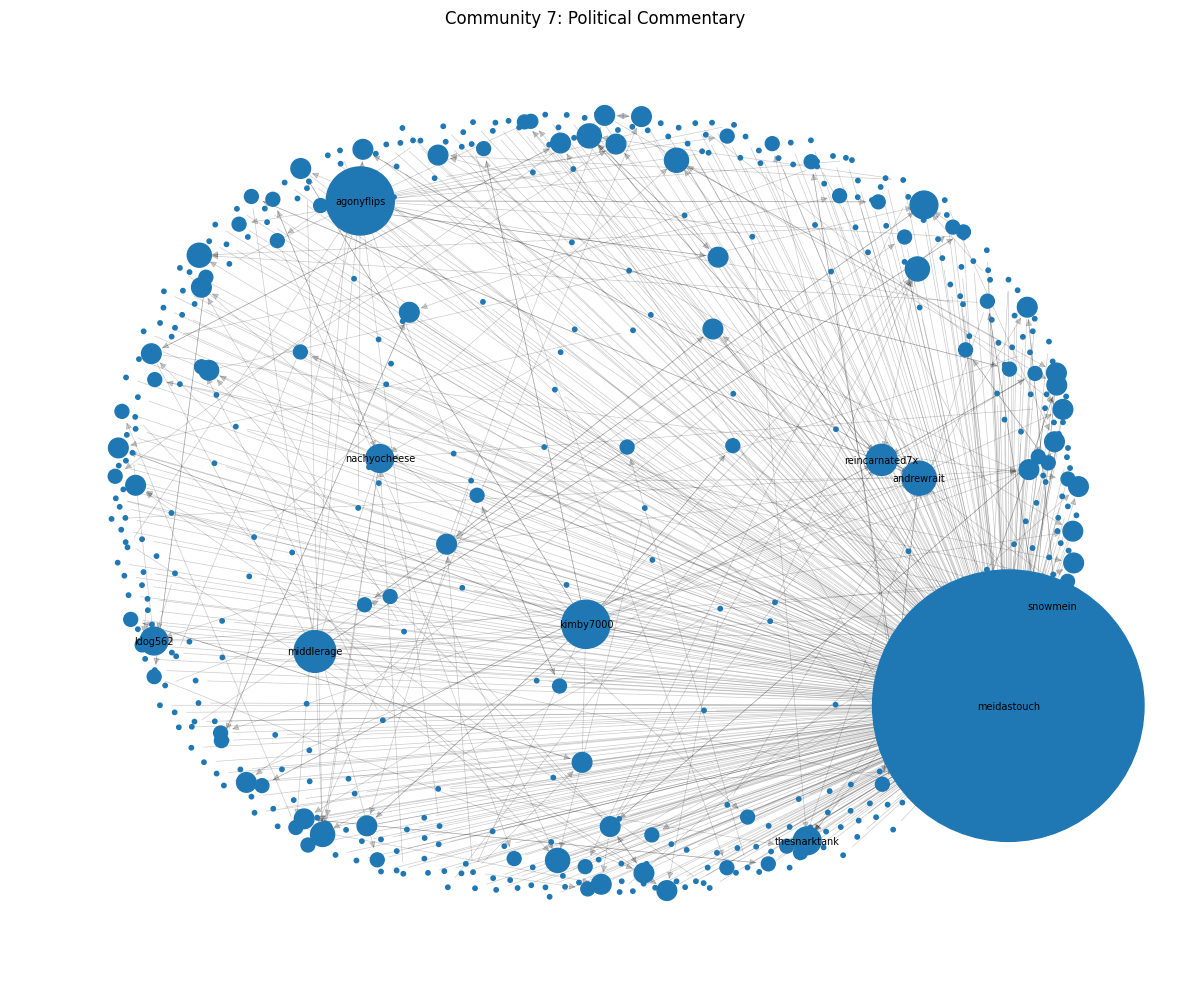

In [34]:
#Code adapated from: https://networkx.org/documentation/stable/auto_examples/drawing/plot_degree.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.in_degree.html
#Code adapted from: https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_labels.html
#Code adapted from: https://medium.com/@jainsnehasj6/networkx-for-python-a-practical-guide-to-graphs-visualization-and-traversals-35106cfee2ea
#Plot a subgraph for the different types of communities 
#Get users in community 7 (Political commentary) and create a subgraph
c7_users = community_users.get(7, [])
c7_subgraph = replyGraph.subgraph(c7_users)

#Graph will have nodes sized by in_degree
id_7 = dict(c7_subgraph.in_degree())
nodes_size = [max(10, id_7.get(n, 0) * 100) for n in c7_subgraph.nodes()]

#Output the network nodes and edges in python
pos = nx.spring_layout(c7_subgraph, seed=42, k=0.8) #Yes
plt.figure(figsize=(12, 10)) #Yes
nx.draw_networkx_nodes(c7_subgraph, pos, node_size=nodes_size) #Yes
nx.draw_networkx_edges(c7_subgraph, pos, alpha=0.2, arrows=True, width=0.5) #Yes

#Ensure only the top 10 largest nodes are labelled (for report clarity)
most_id7 = sorted(id_7.items(), key=lambda x: x[1], reverse=True)[:10]
labels7 = {node: node.split('.')[0] for node, deg in most_id7}

#Output the labels and display the entire subgraph network
nx.draw_networkx_labels(c7_subgraph, pos, labels=labels7, font_size=7) 
plt.title("Community 7: Political Commentary")
plt.axis('off')
plt.tight_layout()
plt.show()

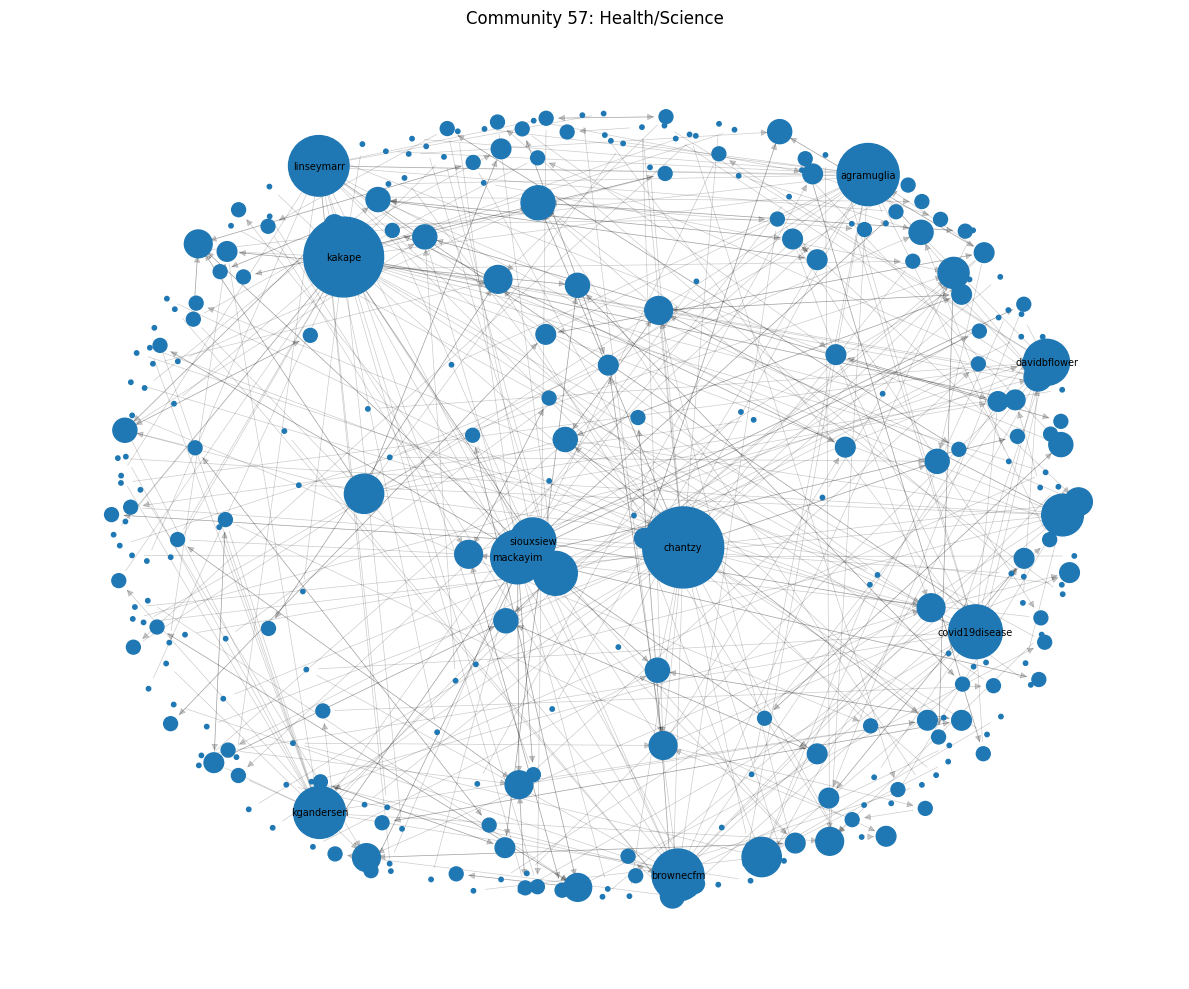

In [35]:
#Code adapated from: https://networkx.org/documentation/stable/auto_examples/drawing/plot_degree.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.in_degree.html
#Code adapted from: https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_labels.html
#Code adapted from: https://medium.com/@jainsnehasj6/networkx-for-python-a-practical-guide-to-graphs-visualization-and-traversals-35106cfee2ea
#Plot a subgraph for the different types of communities 
#Get users in community 26 (Health) and create a subgraph
c57_users = community_users.get(57, [])
c57_subgraph = replyGraph.subgraph(c57_users)

#Graph will have nodes sized by in_degree
id_57 = dict(c57_subgraph.in_degree())
nodes_size57 = [max(10, id_57.get(n, 0) * 100) for n in c57_subgraph.nodes()]

#Output the network nodes and edges in python
pos = nx.spring_layout(c57_subgraph, seed=42, k=0.8) #Yes
plt.figure(figsize=(12, 10)) #Yes
nx.draw_networkx_nodes(c57_subgraph, pos, node_size=nodes_size57) #Yes
nx.draw_networkx_edges(c57_subgraph, pos, alpha=0.2, arrows=True, width=0.5) #Yes

#Ensure only the top 10 largest nodes are labelled (for report clarity)
most_id57 = sorted(id_57.items(), key=lambda x: x[1], reverse=True)[:10]
labels57 = {node: node.split('.')[0] for node, deg in most_id57}

#Output the labels and display the entire subgraph network
nx.draw_networkx_labels(c57_subgraph, pos, labels=labels57, font_size=7) 
plt.title("Community 57: Health/Science")
plt.axis('off')
plt.tight_layout()
plt.show()

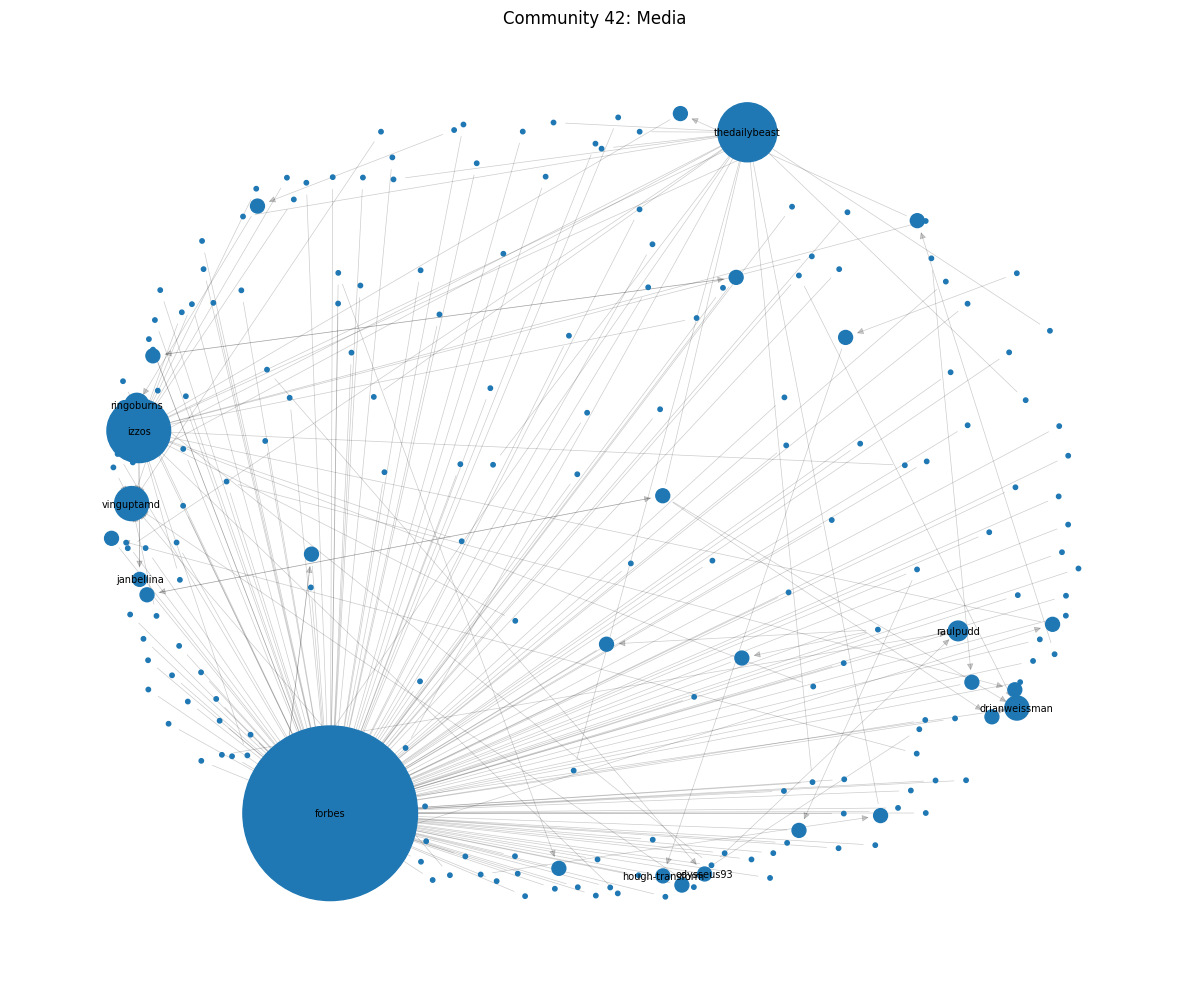

In [36]:
#Code adapated from: https://networkx.org/documentation/stable/auto_examples/drawing/plot_degree.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.in_degree.html
#Code adapted from: https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_labels.html
#Code adapted from: https://medium.com/@jainsnehasj6/networkx-for-python-a-practical-guide-to-graphs-visualization-and-traversals-35106cfee2ea
#Plot a subgraph for the different types of communities 
#Get users in community 42 (Media) and create a subgraph
c42_users = community_users.get(42, [])
c42_subgraph = replyGraph.subgraph(c42_users)

#Graph will have nodes sized by in_degree
id_42 = dict(c42_subgraph.in_degree())
nodes_size42 = [max(10, id_42.get(n, 0) * 100) for n in c42_subgraph.nodes()]

#Output the network nodes and edges in python
pos = nx.spring_layout(c42_subgraph, seed=42, k=0.8) #Yes
plt.figure(figsize=(12, 10)) #Yes
nx.draw_networkx_nodes(c42_subgraph, pos, node_size=nodes_size42) #Yes
nx.draw_networkx_edges(c42_subgraph, pos, alpha=0.2, arrows=True, width=0.5) #Yes

#Ensure only the top 10 largest nodes are labelled (for report clarity)
most_id42 = sorted(id_42.items(), key=lambda x: x[1], reverse=True)[:10]
labels42 = {node: node.split('.')[0] for node, deg in most_id42}

#Output the labels and display the entire subgraph network
nx.draw_networkx_labels(c42_subgraph, pos, labels=labels42, font_size=7) 
plt.title("Community 42: Media")
plt.axis('off')
plt.tight_layout()
plt.show()

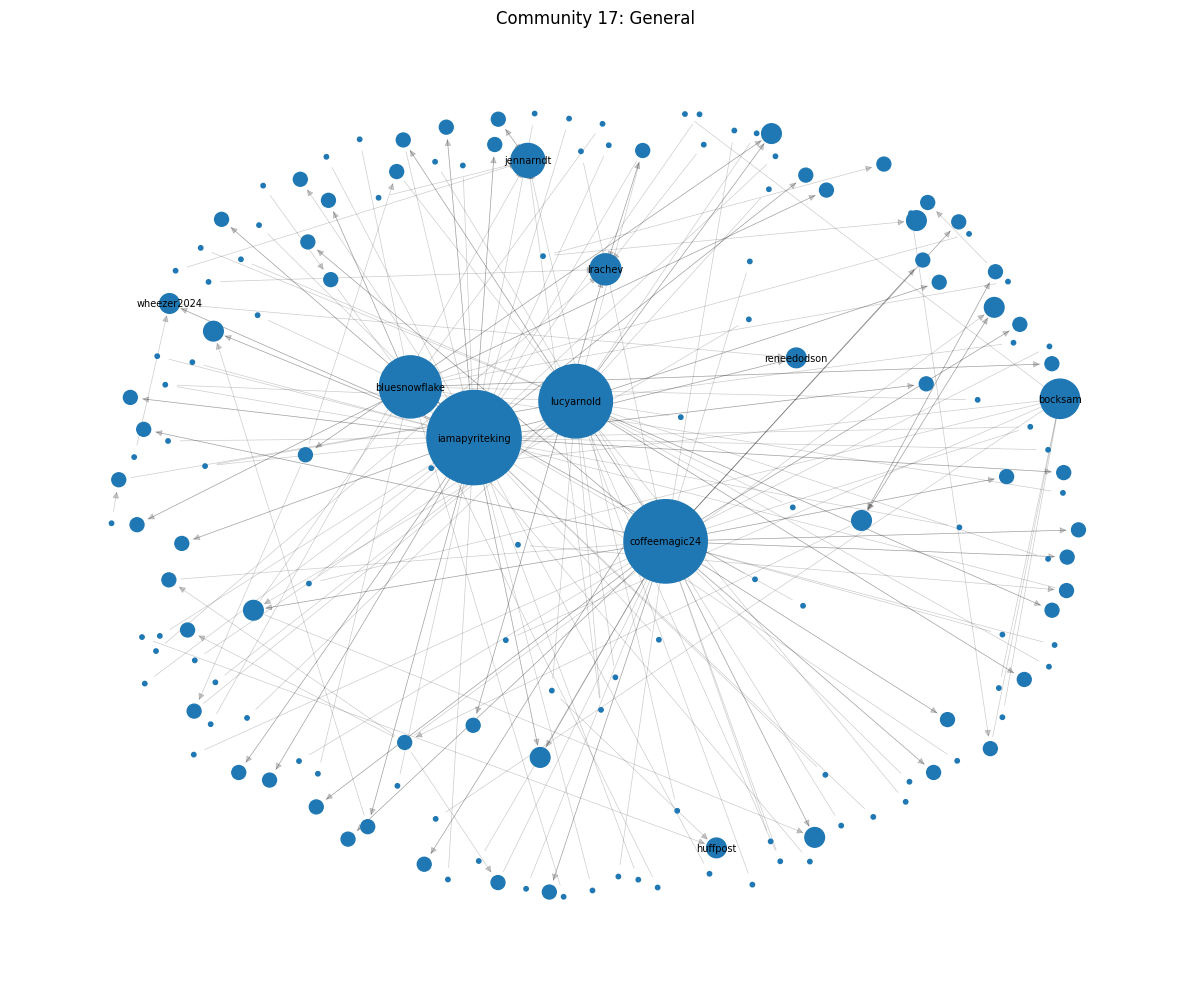

In [37]:
#Code adapated from: https://networkx.org/documentation/stable/auto_examples/drawing/plot_degree.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html
#Code adapated from: https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.in_degree.html
#Code adapted from: https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw_networkx_labels.html
#Code adapted from: https://medium.com/@jainsnehasj6/networkx-for-python-a-practical-guide-to-graphs-visualization-and-traversals-35106cfee2ea
#Plot a subgraph for the different types of communities 
#Get users in community 17 (General) and create a subgraph
c17_users = community_users.get(17, [])
c17_subgraph = replyGraph.subgraph(c17_users)

#Graph will have nodes sized by in_degree
id_17 = dict(c17_subgraph.in_degree())
nodes_size17 = [max(10, id_17.get(n, 0) * 100) for n in c17_subgraph.nodes()]

#Output the network nodes and edges in python
pos = nx.spring_layout(c17_subgraph, seed=42, k=0.8) #Yes
plt.figure(figsize=(12, 10)) #Yes
nx.draw_networkx_nodes(c17_subgraph, pos, node_size=nodes_size17) #Yes
nx.draw_networkx_edges(c17_subgraph, pos, alpha=0.2, arrows=True, width=0.5) #Yes

#Ensure only the top 10 largest nodes are labelled (for report clarity)
most_id17 = sorted(id_17.items(), key=lambda x: x[1], reverse=True)[:10]
labels17 = {node: node.split('.')[0] for node, deg in most_id17}

#Output the labels and display the entire subgraph network
nx.draw_networkx_labels(c17_subgraph, pos, labels=labels17, font_size=7) 
plt.title("Community 17: General")
plt.axis('off')
plt.tight_layout()
plt.show()

---
### Central user sentiment vs community
This section of the code will compare the sentiment of central figures within communities to the rest of the community to assist in determining wheter central figures sentiment is correlated to other users sentiment within a community.

In [39]:
#Estbalish the central users by in-degree centrality
#This will be used to assist with plotting and gathering posts from central users
community_central_users = {7: "meidastouch.com", 31: "atrupar.com", 57: "chantzy.bsky.social", 35: "cwebbonline.com",
                           10: "thev.bsky.social", 1: "briantylercohen.bsky.social", 62: "elizabethjacobs.bsky.social",
                           40: "acyn.bsky.social", 43: "muellershewrote.com", 42: "forbes.com", 151: "kylegriffin1.bsky.social",
                           33: "reuters.com", 19: "downwithdan.bsky.social", 58: "onestpress.onestnetwork.com", 6: "robdelaney.bsky.social",
                           17: "iamapyriteking.bsky.social", 53: "apnews.com", 79: "sailorrooscout.bsky.social", 51: "pbsnews.org", 9: "thebulwark.com"}

In [40]:
#Code to gather the average sentiment of central users vs other users
#Store results to use in the later plot.
results = []

#Run for each central user in the communities
for community_id, central_user in community_central_users.items():

    #List to store central users posts and other users posts
    central_user_posts = []
    other_posts = []

    #Split posts and store as either by the central user or by another user in the community
    for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
        if post_community == community_id:
            if post_author == central_user:
                central_user_posts.append((post_author, post_date, post_text, post_likes, post_reposts, post_community))
            else:
                other_posts.append((post_author, post_date, post_text, post_likes, post_reposts, post_community))

    #Pre-process the text for central users
    central_SA_comments = [(post_date, processTextSA(text=clean_for_sentiment(post_text),
                                                     tokenizer=tweetTokeniser,
                                                     stopwords=lStopwords)) for author, post_date, post_text, *_ in central_user_posts]

    #Pre-process the text for other users
    other_SA_comments = [(post_date, processTextSA(text=clean_for_sentiment(post_text),
                                                   tokenizer=tweetTokeniser,
                                                   stopwords=lStopwords)) for author, post_date, post_text, *_ in other_posts]

    #Calculate sentiment for the two different types of posts
    central_sentiment = vaderSentimentAnalysis1(central_SA_comments, flagPrint)
    other_sentiment   = vaderSentimentAnalysis1(other_SA_comments, flagPrint)

    #Calculate the average sentiment 
    central_scores = [s for date, s in central_sentiment]
    other_scores   = [s for date, s in other_sentiment]
    central_avg = sum(central_scores) / len(central_scores) if central_scores else 0
    other_avg   = sum(other_scores) / len(other_scores) if other_scores else 0

    results.append({"community": community_id, "central_user": central_user, "central_avg": central_avg, "other_avg": other_avg})

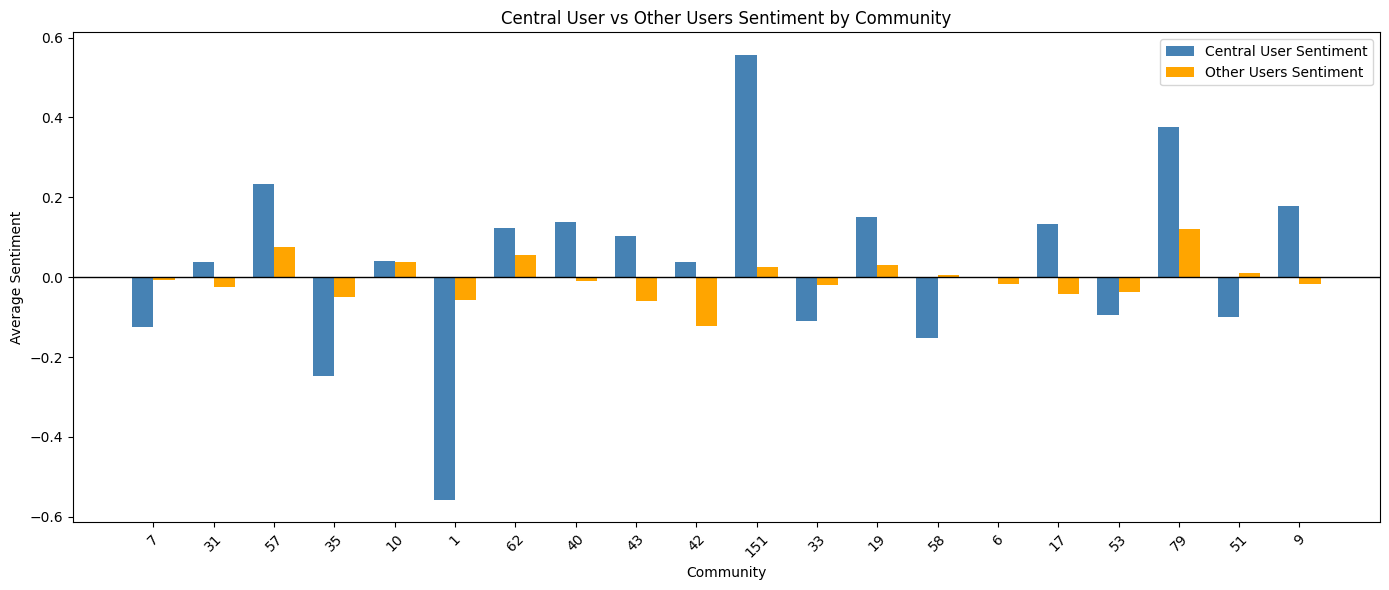

In [41]:
#Code adapted from: https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html
#Code adapted from: https://www.geeksforgeeks.org/python/diverging-bar-chart-using-python/
#Plot the central user and other users sentiment scores (average compound)
communities = [r["community"] for r in results]
central_avg = [r["central_avg"] for r in results]
other_avg = [r["other_avg"] for r in results]

#Build a plot with different bars depending on either central user or other user
x = np.arange(len(communities))
width = 0.35
plt.figure(figsize=(14,6))

#Central user bars
plt.bar(x - width/2,
        central_avg,
        width,
        label='Central User Sentiment',
        color='steelblue')

#Other users bars
plt.bar(x + width/2,
        other_avg,
        width,
        label='Other Users Sentiment',
        color='orange')

#Output the graph
plt.xlabel('Community')
plt.ylabel('Average Sentiment')
plt.title('Central User vs Other Users Sentiment by Community')
plt.xticks(x, communities, rotation=45)
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

---
### Save communties CSV for use in other file
This section of code will save a CSV file for use in other files based on community allocation to certain nodes/users.

In [43]:
'''
#CSV to store posts along with community
#For use in other files
export_rows = []

for post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:
    export_rows.append({'author': post_author,
                        'date': post_date,
                        'text': post_text,
                        'likes': post_likes,
                        'reposts': post_reposts,
                        'community': post_community,})

export_df = pd.DataFrame(export_rows)
export_df.to_csv('hanta_posts_with_community.csv', index=False)

'''

"\n#CSV to store posts along with community\n#For use in other files\nexport_rows = []\n\nfor post_author, post_date, post_text, post_likes, post_reposts, post_community in English_posts:\n    export_rows.append({'author': post_author,\n                        'date': post_date,\n                        'text': post_text,\n                        'likes': post_likes,\n                        'reposts': post_reposts,\n                        'community': post_community,})\n\nexport_df = pd.DataFrame(export_rows)\nexport_df.to_csv('hanta_posts_with_community.csv', index=False)\n\n"